# 📈 Previsão de Séries Temporais Financeiras com LSTM
## Redes Neurais Recorrentes Avançadas — LSTM & Variantes

---

### 🎯 Objetivos do Projeto

Este notebook explora o uso de **Long Short-Term Memory (LSTM)** e suas variantes para prever preços de ações a partir de dados históricos, com os seguintes objetivos:

- Utilizar a **API do Kaggle** para obter dados reais de mercado financeiro
- Realizar **Análise Exploratória de Dados (EDA)** completa
- Engenharia de Features com **indicadores técnicos** (SMA, EMA, RSI, MACD, Bollinger Bands)
- Implementar e comparar **três arquiteturas**: LSTM, BiLSTM e LSTM+GRU
- Avaliar com métricas robustas: **MAE, RMSE, MAPE e R²**
- Gerar previsões com **estimativa de incerteza** via Monte Carlo Dropout
- Realizar previsão **multi-step** de dias futuros

---

### 📚 Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 1. Configuração | Kaggle API, dependências, GPU |
| 2. Dados | Download e exploração (EDA) |
| 3. Engenharia de Features | Indicadores técnicos |
| 4. Pré-processamento | Normalização e janelas temporais |
| 5. Modelos | LSTM, BiLSTM, LSTM+GRU |
| 6. Treinamento | Early stopping, scheduler |
| 7. Avaliação | Métricas e visualizações |
| 8. Incerteza | Monte Carlo Dropout |
| 9. Previsão Futura | Forecast multi-step |

---
## ⚙️ Seção 1 — Configuração do Ambiente

In [17]:
# 1.1 — Verificar acelerador GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('✅ GPU disponível!')
    print(result.stdout[:300])
else:
    print('⚠️  Sem GPU — usando CPU. Para ativar: Ambiente de execução > Alterar tipo > T4 GPU')

✅ GPU disponível!
Thu Mar 26 22:53:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------


In [18]:
# 1.2 — Instalar dependências
!pip install kaggle --quiet
!pip install torch torchvision torchaudio --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print('✅ Dependências instaladas com sucesso!')

✅ Dependências instaladas com sucesso!


### 🔑 Configuração da API do Kaggle

Para usar a API do Kaggle no Colab, siga os passos:

1. Acesse [kaggle.com](https://www.kaggle.com) → Sua conta → **Account**
2. Role até a seção **API** → clique em **Create New Token**
3. O arquivo `kaggle.json` será baixado
4. Execute a célula abaixo e faça o upload do arquivo

In [21]:
# 1.3 — Upload do kaggle.json (execute no Colab)
import os

try:
    from google.colab import files
    print('📤 Selecione o arquivo kaggle.json:')
    uploaded = files.upload()

    os.makedirs('/root/.config/kaggle', exist_ok=True)
    import shutil
    shutil.move('kaggle.json', '/root/.config/kaggle/kaggle.json')
    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
    print('✅ Credenciais configuradas!')

except Exception as e:
    print(f'❌ Erro: {e}')

📤 Selecione o arquivo kaggle.json:


Saving kaggle.json to kaggle.json
✅ Credenciais configuradas!


In [22]:
# 1.4 — Download do dataset via Kaggle API
# Dataset: Histórico de preços de ações de grandes empresas de tecnologia
# Fonte: Kaggle — meetnagadia/apple-stock-price-from-19802021-aapl

import os

dataset_name = 'meetnagadia/apple-stock-price-from-19802021-aapl'
output_dir = '/content/stock_data'

os.makedirs(output_dir, exist_ok=True)

try:
    !kaggle datasets download -d {dataset_name} -p {output_dir} --unzip
    print('✅ Dataset baixado com sucesso!')
    !ls {output_dir}
except Exception as e:
    print(f'⚠️  Falha no download Kaggle: {e}')
    print('🔄 Usando fallback: yfinance...')
    !pip install yfinance --quiet
    import yfinance as yf
    import pandas as pd
    df_fb = yf.download('AAPL', start='2010-01-01', end='2024-01-01', progress=False)
    df_fb.to_csv(f'{output_dir}/AAPL_Historical_Data.csv')
    print('✅ Dados obtidos via yfinance como fallback!')

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
✅ Dataset baixado com sucesso!
AAPL_Historical_Data.csv


In [23]:
# 1.5 — Imports e configurações globais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
import math
from copy import deepcopy

warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Dispositivo: {DEVICE}')

# Hiperparâmetros globais
SEQ_LEN    = 60    # Janela temporal: 60 dias de observação
BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3
PATIENCE   = 15    # Early stopping
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.3

print('✅ Configurações carregadas!')

🖥️  Dispositivo: cuda
✅ Configurações carregadas!


---
## 📊 Seção 2 — Carregamento e Análise Exploratória dos Dados (EDA)

In [24]:
import os
import yfinance as yf

os.makedirs('/content/stock_data', exist_ok=True)

df_temp = yf.download('AAPL', start='2010-01-01', end='2024-01-01', progress=False)
df_temp.reset_index(inplace=True)  # <-- isso transforma a data em coluna
df_temp.columns = df_temp.columns.get_level_values(0)  # achata multi-index
df_temp.to_csv('/content/stock_data/AAPL_Historical_Data.csv', index=False)
print('✅ Arquivo salvo corretamente!')
print(df_temp.columns.tolist())

✅ Arquivo salvo corretamente!
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [25]:
# 2.1 — Carregar e preparar dataset
import glob

csv_files = glob.glob('/content/stock_data/**/*.csv', recursive=True)
if not csv_files:
    csv_files = glob.glob('/content/stock_data/*.csv')

print(f'📁 Arquivos encontrados: {csv_files}')
df_raw = pd.read_csv(csv_files[0])

# Normalizar colunas
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')

# Mapear nomes comuns de colunas
col_map = {}
for col in df_raw.columns:
    if 'date' in col:  col_map[col] = 'date'
    if 'open' in col:  col_map[col] = 'open'
    if 'high' in col:  col_map[col] = 'high'
    if 'low'  in col:  col_map[col] = 'low'
    if 'close' in col and 'adj' not in col: col_map[col] = 'close'
    if 'adj' in col and 'close' in col: col_map[col] = 'adj_close'
    if 'vol' in col:   col_map[col] = 'volume'

df_raw.rename(columns=col_map, inplace=True)

# Usar adj_close se disponível, senão close
if 'adj_close' in df_raw.columns:
    df_raw['close'] = df_raw['adj_close']

# Converter data e ordenar
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw.sort_values('date', inplace=True)
df_raw.reset_index(drop=True, inplace=True)

# Remover linhas com NaN
df_raw.dropna(subset=['close'], inplace=True)

print(f'\n📋 Shape: {df_raw.shape}')
print(f'📅 Período: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'📈 Colunas: {list(df_raw.columns)}')
df_raw.head()

📁 Arquivos encontrados: ['/content/stock_data/AAPL_Historical_Data.csv']

📋 Shape: (3522, 6)
📅 Período: 2010-01-04 → 2023-12-29
📈 Colunas: ['date', 'close', 'high', 'low', 'open', 'volume']


,date,close,high,low,open,volume
0,2010-01-04,6.412385,6.427066,6.363545,6.395006,493729600
1,2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800
2,2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000
3,2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200
4,2010-01-08,6.351557,6.352157,6.264066,6.301219,447610800


In [26]:
# 2.2 — Estatísticas descritivas
print('=' * 60)
print('📊 ESTATÍSTICAS DESCRITIVAS')
print('=' * 60)
print(df_raw[['open', 'high', 'low', 'close', 'volume']].describe().T.round(2).to_string())
print(f'\n🔍 Valores nulos:\n{df_raw.isnull().sum()}')

📊 ESTATÍSTICAS DESCRITIVAS
         count          mean           std          min          25%           50%           75%           max
open    3522.0  5.728000e+01  5.522000e+01         5.76        16.89  2.891000e+01  8.840000e+01  1.959800e+02
high    3522.0  5.790000e+01  5.585000e+01         5.87        17.03  2.913000e+01  8.966000e+01  1.975700e+02
low     3522.0  5.669000e+01  5.465000e+01         5.70        16.71  2.866000e+01  8.763000e+01  1.949700e+02
close   3522.0  5.732000e+01  5.528000e+01         5.75        16.88  2.891000e+01  8.839000e+01  1.960700e+02
volume  3522.0  2.422839e+08  2.204575e+08  24048300.00  92667600.00  1.526602e+08  3.284715e+08  1.880998e+09

🔍 Valores nulos:
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


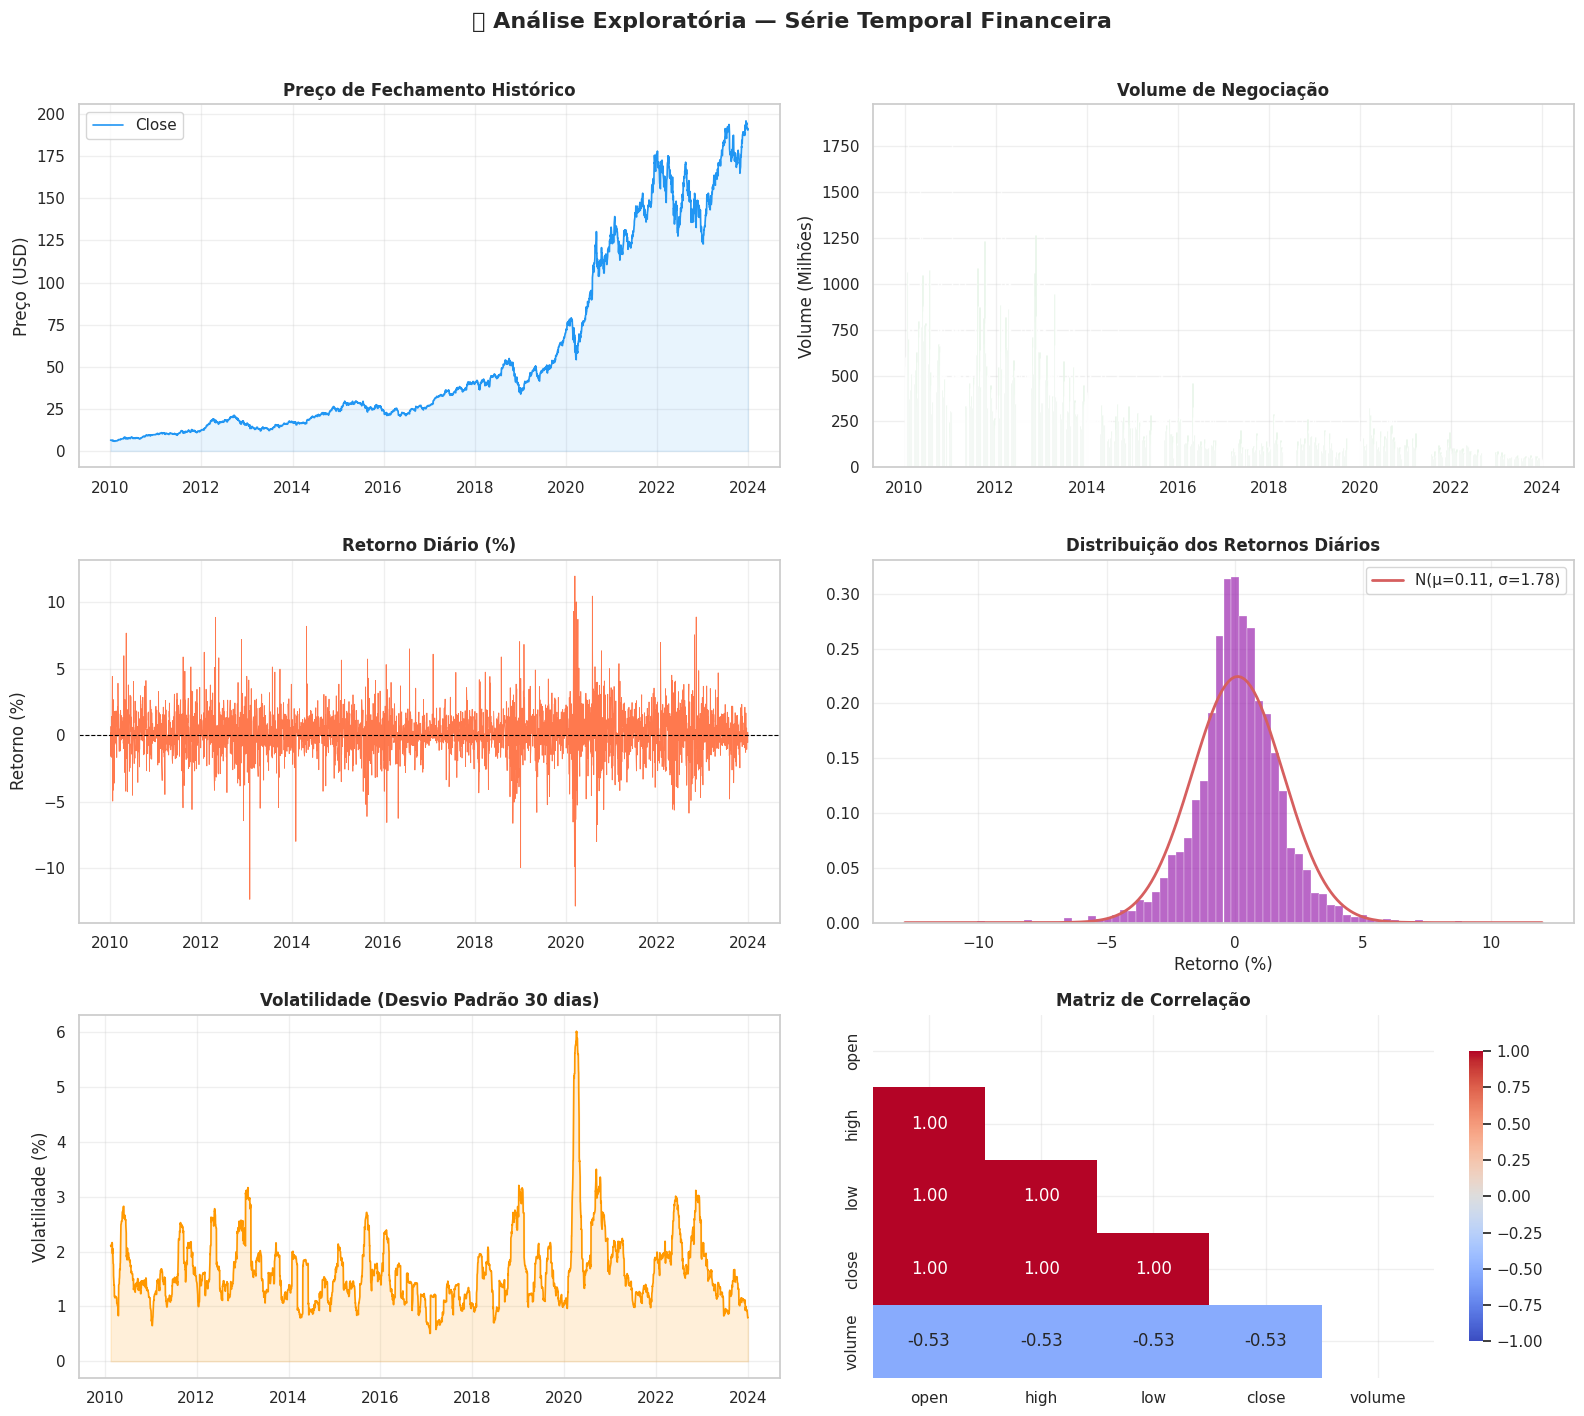


📌 Insights principais:
  • Assimetria dos retornos: -0.0606
  • Curtose dos retornos: 5.1819 (caudas pesadas!)
  • Retorno médio diário: 0.1122%
  • Volatilidade média (desvio padrão): 1.7764%


In [27]:
# 2.3 — Visualização EDA completa
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('📊 Análise Exploratória — Série Temporal Financeira', fontsize=16, fontweight='bold', y=1.01)

# 1. Preço de fechamento histórico
axes[0,0].plot(df_raw['date'], df_raw['close'], color='#2196F3', linewidth=1.2, label='Close')
axes[0,0].fill_between(df_raw['date'], df_raw['close'], alpha=0.1, color='#2196F3')
axes[0,0].set_title('Preço de Fechamento Histórico', fontweight='bold')
axes[0,0].set_ylabel('Preço (USD)')
axes[0,0].legend()

# 2. Volume de negociação
axes[0,1].bar(df_raw['date'], df_raw['volume'] / 1e6, color='#4CAF50', alpha=0.7, width=0.8)
axes[0,1].set_title('Volume de Negociação', fontweight='bold')
axes[0,1].set_ylabel('Volume (Milhões)')

# 3. Retorno diário (%)
df_raw['daily_return'] = df_raw['close'].pct_change() * 100
axes[1,0].plot(df_raw['date'], df_raw['daily_return'], color='#FF5722', linewidth=0.6, alpha=0.8)
axes[1,0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('Retorno Diário (%)', fontweight='bold')
axes[1,0].set_ylabel('Retorno (%)')

# 4. Histograma dos retornos (distribuição)
returns_clean = df_raw['daily_return'].dropna()
mu, sigma = returns_clean.mean(), returns_clean.std()
axes[1,1].hist(returns_clean, bins=80, color='#9C27B0', alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
x = np.linspace(returns_clean.min(), returns_clean.max(), 200)
from scipy.stats import norm
axes[1,1].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'N(μ={mu:.2f}, σ={sigma:.2f})')
axes[1,1].set_title('Distribuição dos Retornos Diários', fontweight='bold')
axes[1,1].set_xlabel('Retorno (%)')
axes[1,1].legend()

# 5. Volatilidade (desvio padrão móvel 30 dias)
df_raw['volatility_30'] = df_raw['daily_return'].rolling(30).std()
axes[2,0].plot(df_raw['date'], df_raw['volatility_30'], color='#FF9800', linewidth=1.2)
axes[2,0].fill_between(df_raw['date'], df_raw['volatility_30'], alpha=0.15, color='#FF9800')
axes[2,0].set_title('Volatilidade (Desvio Padrão 30 dias)', fontweight='bold')
axes[2,0].set_ylabel('Volatilidade (%)')

# 6. Correlação entre features
corr_cols = ['open', 'high', 'low', 'close', 'volume']
corr = df_raw[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2,1], mask=mask,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[2,1].set_title('Matriz de Correlação', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insights principais:')
print(f'  • Assimetria dos retornos: {returns_clean.skew():.4f}')
print(f'  • Curtose dos retornos: {returns_clean.kurtosis():.4f} (caudas pesadas!)')
print(f'  • Retorno médio diário: {mu:.4f}%')
print(f'  • Volatilidade média (desvio padrão): {sigma:.4f}%')

---
## 🔧 Seção 3 — Engenharia de Features: Indicadores Técnicos

Indicadores técnicos transformam a série de preços em sinais úteis para o modelo:

| Indicador | Tipo | O que captura |
|---|---|---|
| SMA (7, 21, 50 dias) | Tendência | Média de preços |
| EMA (12, 26 dias) | Tendência | Média ponderada (mais reativa) |
| RSI (14 dias) | Momentum | Sobrecompra/Sobrevenda (0–100) |
| MACD | Momentum | Divergência de médias |
| Bandas de Bollinger | Volatilidade | Desvios da média |
| ATR | Volatilidade | Amplitude média real |
| OBV | Volume | Confirmação de tendência por volume |

In [28]:
# 3.1 — Funções de indicadores técnicos
def add_technical_indicators(df):
    """Adiciona indicadores técnicos ao DataFrame."""
    d = df.copy()
    c = d['close']

    # === Médias Móveis ===
    for w in [7, 21, 50]:
        d[f'sma_{w}'] = c.rolling(w).mean()

    # EMA (Média Móvel Exponencial)
    for w in [12, 26]:
        d[f'ema_{w}'] = c.ewm(span=w, adjust=False).mean()

    # === MACD ===
    d['macd']        = d['ema_12'] - d['ema_26']
    d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()
    d['macd_hist']   = d['macd'] - d['macd_signal']

    # === RSI (Índice de Força Relativa) ===
    window = 14
    delta  = c.diff()
    gain   = delta.clip(lower=0).rolling(window).mean()
    loss   = (-delta.clip(upper=0)).rolling(window).mean()
    rs     = gain / (loss + 1e-10)
    d['rsi'] = 100 - (100 / (1 + rs))

    # === Bandas de Bollinger ===
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    d['bb_upper'] = bb_mid + 2 * bb_std
    d['bb_lower'] = bb_mid - 2 * bb_std
    d['bb_mid']   = bb_mid
    d['bb_width'] = (d['bb_upper'] - d['bb_lower']) / bb_mid  # Largura normalizada
    d['bb_pct']   = (c - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-10)

    # === ATR (Average True Range — Volatilidade) ===
    high_low     = d['high'] - d['low']
    high_close   = (d['high'] - c.shift(1)).abs()
    low_close    = (d['low']  - c.shift(1)).abs()
    true_range   = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    d['atr_14']  = true_range.rolling(14).mean()

    # === OBV (On-Balance Volume) ===
    obv = [0]
    for i in range(1, len(d)):
        if d['close'].iloc[i] > d['close'].iloc[i-1]:
            obv.append(obv[-1] + d['volume'].iloc[i])
        elif d['close'].iloc[i] < d['close'].iloc[i-1]:
            obv.append(obv[-1] - d['volume'].iloc[i])
        else:
            obv.append(obv[-1])
    d['obv'] = obv
    d['obv'] = d['obv'] / 1e8  # Normalização de escala

    # === Retorno logarítmico ===
    d['log_return'] = np.log(c / c.shift(1))

    # === Momentum (price change) ===
    d['momentum_10'] = c.pct_change(10)

    return d

df = add_technical_indicators(df_raw)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'📊 Features criadas: {df.shape[1]} colunas')
print(f'📅 Registros restantes: {len(df)}')
df.head(3)

📊 Features criadas: 26 colunas
📅 Registros restantes: 3473


,date,close,high,low,open,volume,daily_return,volatility_30,sma_7,sma_21,...,rsi,bb_upper,bb_lower,bb_mid,bb_width,bb_pct,atr_14,obv,log_return,momentum_10
0,2010-03-16,6.725197,6.741078,6.667069,6.717108,446908000,0.272519,1.389944,6.708846,6.334280,...,90.199317,6.964313,5.728227,6.346270,0.194774,0.806554,0.117626,76.778408,0.002721,0.074695
1,2010-03-17,6.715309,6.785123,6.689841,6.738680,450956800,-0.147032,1.394541,6.730419,6.363843,...,88.698268,7.003139,5.754031,6.378585,0.195828,0.769572,0.111655,72.268840,-0.001471,0.070654
2,2010-03-18,6.731192,6.741679,6.670067,6.714711,342109600,0.236512,1.374446,6.737396,6.395376,...,87.806627,7.038074,5.784176,6.411125,0.195582,0.755257,0.109985,75.689936,0.002362,0.066158


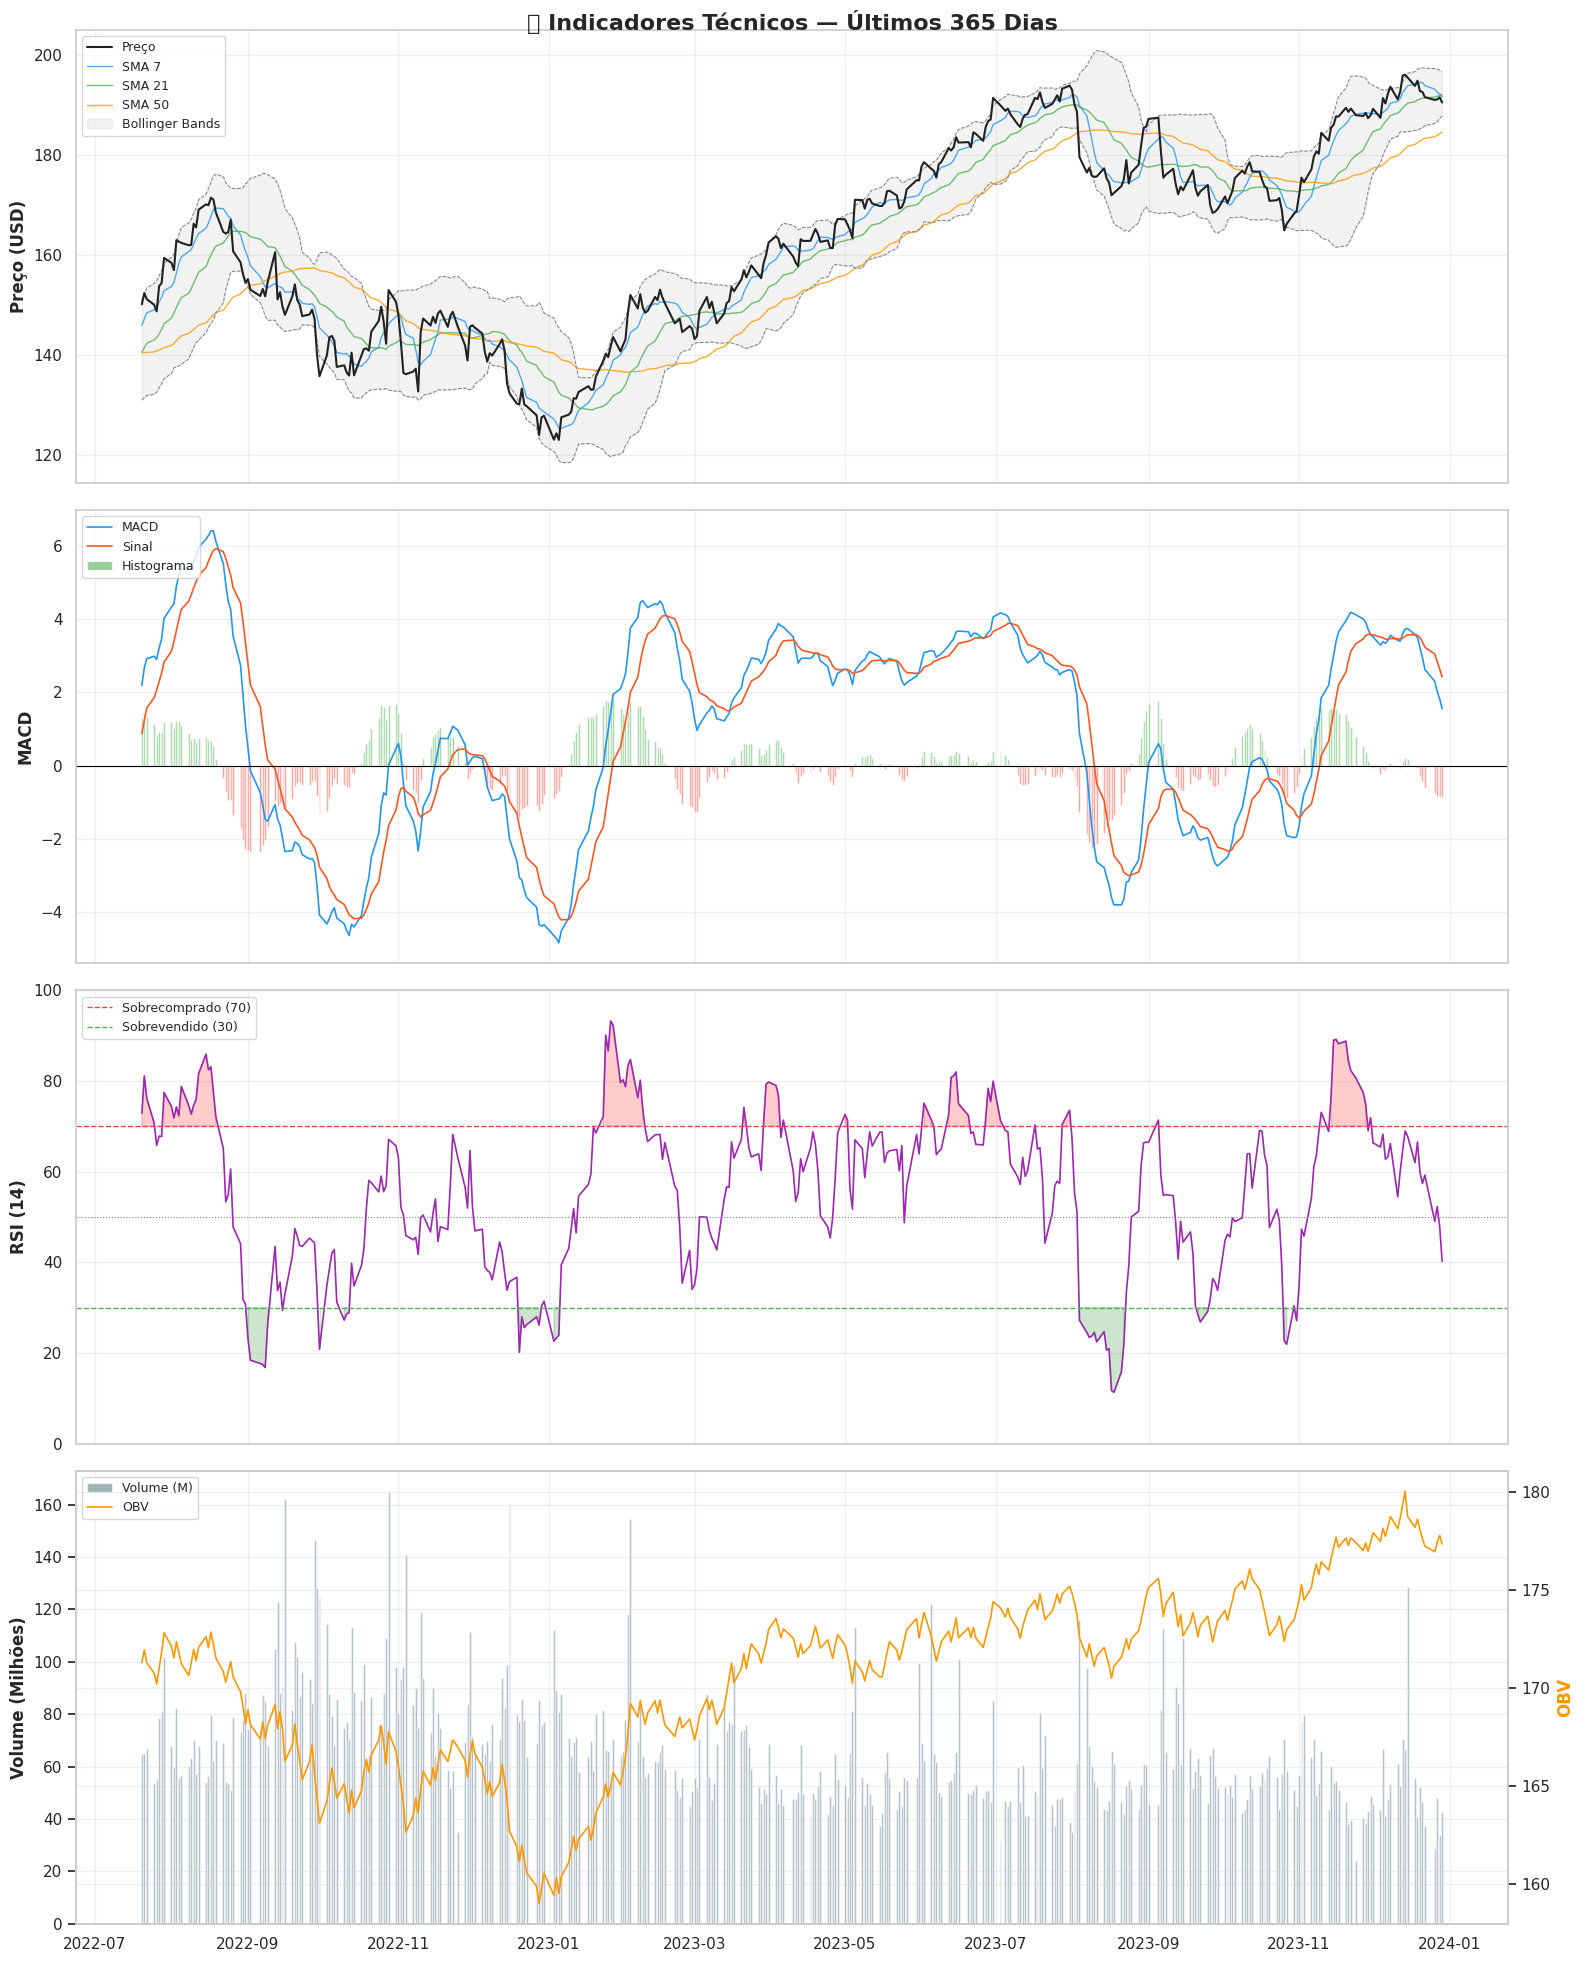

In [29]:
# 3.2 — Visualização dos indicadores técnicos
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
fig.suptitle('📈 Indicadores Técnicos — Últimos 365 Dias', fontsize=16, fontweight='bold')

# Mostrar apenas último ano para melhor visualização
df_plot = df.tail(365).copy()

# 1. Preço + Médias Móveis + Bollinger Bands
ax = axes[0]
ax.plot(df_plot['date'], df_plot['close'],   color='#212121', linewidth=1.5, label='Preço', zorder=5)
ax.plot(df_plot['date'], df_plot['sma_7'],   color='#2196F3', linewidth=1, alpha=0.8, label='SMA 7')
ax.plot(df_plot['date'], df_plot['sma_21'],  color='#4CAF50', linewidth=1, alpha=0.8, label='SMA 21')
ax.plot(df_plot['date'], df_plot['sma_50'],  color='#FF9800', linewidth=1, alpha=0.8, label='SMA 50')
ax.fill_between(df_plot['date'], df_plot['bb_lower'], df_plot['bb_upper'], alpha=0.1, color='gray', label='Bollinger Bands')
ax.plot(df_plot['date'], df_plot['bb_upper'], color='gray', linewidth=0.7, linestyle='--')
ax.plot(df_plot['date'], df_plot['bb_lower'], color='gray', linewidth=0.7, linestyle='--')
ax.set_ylabel('Preço (USD)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# 2. MACD
ax = axes[1]
ax.plot(df_plot['date'], df_plot['macd'],        color='#2196F3', linewidth=1.2, label='MACD')
ax.plot(df_plot['date'], df_plot['macd_signal'], color='#FF5722', linewidth=1.2, label='Sinal')
colors_hist = ['#4CAF50' if v >= 0 else '#F44336' for v in df_plot['macd_hist']]
ax.bar(df_plot['date'], df_plot['macd_hist'], color=colors_hist, alpha=0.6, width=0.8, label='Histograma')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('MACD', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# 3. RSI
ax = axes[2]
ax.plot(df_plot['date'], df_plot['rsi'], color='#9C27B0', linewidth=1.2)
ax.axhline(y=70, color='#F44336', linewidth=1, linestyle='--', label='Sobrecomprado (70)')
ax.axhline(y=30, color='#4CAF50', linewidth=1, linestyle='--', label='Sobrevendido (30)')
ax.axhline(y=50, color='gray',    linewidth=0.8, linestyle=':')
ax.fill_between(df_plot['date'], df_plot['rsi'], 70, where=(df_plot['rsi'] >= 70), alpha=0.2, color='red')
ax.fill_between(df_plot['date'], df_plot['rsi'], 30, where=(df_plot['rsi'] <= 30), alpha=0.2, color='green')
ax.set_ylim(0, 100)
ax.set_ylabel('RSI (14)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# 4. Volume + OBV
ax = axes[3]
ax.bar(df_plot['date'], df_plot['volume'] / 1e6, color='#607D8B', alpha=0.6, width=0.8, label='Volume (M)')
ax2 = ax.twinx()
ax2.plot(df_plot['date'], df_plot['obv'], color='#FF9800', linewidth=1.2, label='OBV')
ax.set_ylabel('Volume (Milhões)', fontweight='bold')
ax2.set_ylabel('OBV', color='#FF9800', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('/content/technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔄 Seção 4 — Pré-processamento e Criação de Sequências Temporais

A entrada para LSTM tem formato **(batch, seq_len, n_features)**:
- `batch`: número de amostras no lote
- `seq_len`: 60 dias de histórico por janela
- `n_features`: todos os indicadores técnicos

In [30]:
# 4.1 — Seleção de features e normalização
FEATURES = [
    'close', 'open', 'high', 'low', 'volume',
    'sma_7', 'sma_21', 'sma_50',
    'ema_12', 'ema_26',
    'macd', 'macd_signal', 'macd_hist',
    'rsi',
    'bb_width', 'bb_pct',
    'atr_14',
    'obv',
    'log_return', 'momentum_10'
]
TARGET = 'close'  # Variável alvo: preço de fechamento
TARGET_IDX = FEATURES.index(TARGET)

df_model = df[FEATURES].copy()

# Normalização Min-Max [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_model.values)

print(f'✅ Features selecionadas: {len(FEATURES)}')
print(f'   Target: {TARGET} (índice {TARGET_IDX})')
print(f'   Shape normalizado: {scaled.shape}')

✅ Features selecionadas: 20
   Target: close (índice 0)
   Shape normalizado: (3473, 20)


In [31]:
# 4.2 — Criação de janelas temporais
def create_sequences(data, seq_len, target_idx):
    """Cria janelas temporais deslizantes (sliding window)."""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i])          # Janela de entrada
        y.append(data[i, target_idx])           # Valor alvo (próximo fechamento)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(scaled, SEQ_LEN, TARGET_IDX)

# Divisão temporal (sem shuffle para preservar a ordem)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST = 0.15

n = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

X_train, y_train = X[:n_train],          y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],    y[n_train+n_val:]

print(f'📊 Divisão dos dados:')
print(f'   Treino : {X_train.shape}  ({len(X_train)/n*100:.1f}%)')
print(f'   Val    : {X_val.shape}    ({len(X_val)/n*100:.1f}%)')
print(f'   Teste  : {X_test.shape}   ({len(X_test)/n*100:.1f}%)')
print(f'\n   Formato input: (batch, {SEQ_LEN} dias, {len(FEATURES)} features)')

📊 Divisão dos dados:
   Treino : (2389, 60, 20)  (70.0%)
   Val    : (511, 60, 20)    (15.0%)
   Teste  : (513, 60, 20)   (15.0%)

   Formato input: (batch, 60 dias, 20 features)


In [32]:
# 4.3 — Dataset e DataLoader PyTorch
class TimeSeriesDataset(Dataset):
    """Dataset customizado para séries temporais."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):             return len(self.X)
    def __getitem__(self, idx):    return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TimeSeriesDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f'✅ DataLoaders criados!')
print(f'   Batches de treino  : {len(train_loader)}')
print(f'   Batches de validação: {len(val_loader)}')
print(f'   Batches de teste   : {len(test_loader)}')

✅ DataLoaders criados!
   Batches de treino  : 37
   Batches de validação: 8
   Batches de teste   : 9


---
## 🧠 Seção 5 — Arquiteturas dos Modelos

### Por que LSTM?

LSTMs resolvem o **problema do gradiente desvanescente** das RNNs simples por meio de três portas:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

- **Porta de esquecimento** $f_t$: decide o que descartar da memória anterior
- **Porta de entrada** $i_t$: decide o que adicionar à memória
- **Porta de saída** $o_t$: decide o que passar para a próxima camada

In [33]:
# 5.1 — Modelo 1: LSTM Vanilla com Atenção
class LSTMModel(nn.Module):
    """
    LSTM clássico com:
    - Múltiplas camadas empilhadas
    - Dropout para regularização
    - Layer normalization
    - Cabeça de regressão com camadas densas
    """
    def __init__(self, input_size, hidden_size=HIDDEN_DIM, num_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = False
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(dropout)

        # Cabeça de regressão
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, (h_n, _) = self.lstm(x)
        # Pegar saída do último passo temporal
        out = self.layer_norm(out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out).squeeze(-1)


# 5.2 — Modelo 2: Bidirectional LSTM
class BiLSTMModel(nn.Module):
    """
    LSTM Bidirecional:
    - Processa a sequência nos dois sentidos (passado → futuro e futuro → passado)
    - O contexto futuro ajuda a entender padrões locais
    - Feature map dobrado: hidden_size * 2
    """
    def __init__(self, input_size, hidden_size=HIDDEN_DIM, num_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.dropout    = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.layer_norm(out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out).squeeze(-1)


# 5.3 — Modelo 3: LSTM + GRU Híbrido
class LSTMGRUModel(nn.Module):
    """
    Arquitetura híbrida:
    - LSTM extrai dependências de longo prazo (3 portas)
    - GRU refina representações com menos parâmetros (2 portas)
    - Combina os pontos fortes de cada arquitetura
    """
    def __init__(self, input_size, hidden_size=HIDDEN_DIM, num_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.gru = nn.GRU(
            input_size  = hidden_size,
            hidden_size = hidden_size // 2,
            num_layers  = 1,
            batch_first = True
        )
        self.layer_norm = nn.LayerNorm(hidden_size // 2)
        self.dropout    = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(),
            nn.Linear(hidden_size // 4, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        gru_out, _  = self.gru(lstm_out)
        out = self.layer_norm(gru_out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out).squeeze(-1)


# Instanciar os modelos
INPUT_SIZE = len(FEATURES)

models = {
    'LSTM':     LSTMModel(INPUT_SIZE).to(DEVICE),
    'BiLSTM':   BiLSTMModel(INPUT_SIZE).to(DEVICE),
    'LSTM+GRU': LSTMGRUModel(INPUT_SIZE).to(DEVICE)
}

# Contagem de parâmetros
print(f'\n{'='*55}')
print(f'{'Modelo':<15} {'Parâmetros':>15} {'Tamanho':>15}')
print(f'{'='*55}')
for name, model in models.items():
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size  = total * 4 / 1024 / 1024
    print(f'{name:<15} {train:>15,} {size:>13.2f} MB')
print(f'{'='*55}')


Modelo               Parâmetros         Tamanho
LSTM                    217,473          0.83 MB
BiLSTM                  582,401          2.22 MB
LSTM+GRU                248,385          0.95 MB


---
## 🏋️ Seção 6 — Treinamento com Early Stopping e Learning Rate Scheduler

In [35]:
# 6.1 — Função de treinamento profissional
def train_model(model, train_loader, val_loader, model_name='Model',
                epochs=EPOCHS, lr=LR, patience=PATIENCE):
    """
    Treinamento com:
    - Adam optimizer com weight decay (L2 regularização)
    - ReduceLROnPlateau: reduz LR quando val_loss estagna
    - Early stopping: para quando não há melhora por `patience` épocas
    - Checkpoint: salva o melhor modelo
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='min', factor=0.5, patience=patience // 3
)
    criterion = nn.HuberLoss(delta=0.1)  # Mais robusto a outliers que MSE

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val_loss  = float('inf')
    best_state     = None
    early_stop_cnt = 0

    for epoch in range(1, epochs + 1):
        # --- Treino ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validação ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds     = model(X_batch)
                val_loss  = criterion(preds, y_batch)
                val_losses.append(val_loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        scheduler.step(val_loss)

        # Checkpoint
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = deepcopy(model.state_dict())
            early_stop_cnt = 0
        else:
            early_stop_cnt += 1

        # Log a cada 10 épocas
        if epoch % 10 == 0 or epoch == 1:
            print(f'[{model_name}] Época {epoch:3d}/{epochs} | '
                  f'Train: {train_loss:.5f} | Val: {val_loss:.5f} | '
                  f'LR: {current_lr:.6f} | Melhor: {best_val_loss:.5f}')

        # Early stopping
        if early_stop_cnt >= patience:
            print(f'⏹️  Early stopping na época {epoch} ({model_name})')
            break

    # Restaurar melhor estado
    model.load_state_dict(best_state)
    print(f'✅ [{model_name}] Melhor val_loss: {best_val_loss:.6f}\n')
    return history


# 6.2 — Treinar todos os modelos
all_histories = {}
for name, model in models.items():
    print(f'\n{'━'*60}')
    print(f'🏋️  Treinando: {name}')
    print(f'{'━'*60}')
    history = train_model(model, train_loader, val_loader, model_name=name)
    all_histories[name] = history


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏋️  Treinando: LSTM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[LSTM] Época   1/80 | Train: 0.00642 | Val: 0.03443 | LR: 0.001000 | Melhor: 0.03443
[LSTM] Época  10/80 | Train: 0.00017 | Val: 0.01797 | LR: 0.000500 | Melhor: 0.01167
⏹️  Early stopping na época 17 (LSTM)
✅ [LSTM] Melhor val_loss: 0.011671


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏋️  Treinando: BiLSTM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[BiLSTM] Época   1/80 | Train: 0.00952 | Val: 0.03667 | LR: 0.001000 | Melhor: 0.03667
[BiLSTM] Época  10/80 | Train: 0.00013 | Val: 0.01844 | LR: 0.000500 | Melhor: 0.01258
⏹️  Early stopping na época 17 (BiLSTM)
✅ [BiLSTM] Melhor val_loss: 0.012583


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏋️  Treinando: LSTM+GRU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[LSTM+GRU] Época   1/80 | Train: 0.00335 | Val: 0.02178 | LR: 0.00100

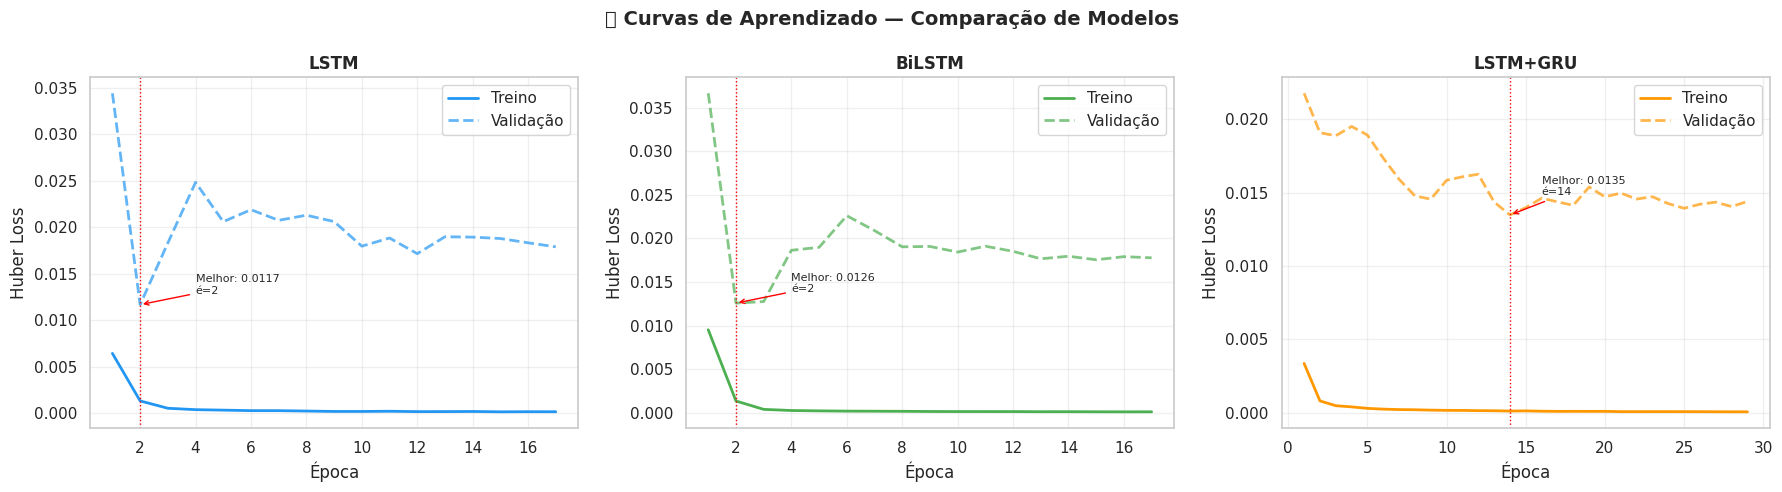

In [36]:
# 6.3 — Curvas de aprendizado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📉 Curvas de Aprendizado — Comparação de Modelos', fontsize=14, fontweight='bold')

colors = {'LSTM': '#2196F3', 'BiLSTM': '#4CAF50', 'LSTM+GRU': '#FF9800'}

for ax, (name, hist) in zip(axes, all_histories.items()):
    epochs_range = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs_range, hist['train_loss'], label='Treino',    color=colors[name], linewidth=2)
    ax.plot(epochs_range, hist['val_loss'],   label='Validação', color=colors[name], linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Huber Loss')
    ax.legend()

    # Marcar melhor val_loss
    best_epoch = np.argmin(hist['val_loss']) + 1
    best_loss  = min(hist['val_loss'])
    ax.axvline(x=best_epoch, color='red', linewidth=1, linestyle=':')
    ax.annotate(f'Melhor: {best_loss:.4f}\né={best_epoch}',
                xy=(best_epoch, best_loss), fontsize=8,
                xytext=(best_epoch + 2, best_loss * 1.1),
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📏 Seção 7 — Avaliação e Comparação de Modelos

In [37]:
# 7.1 — Função de avaliação com métricas completas
def inverse_transform_target(pred_scaled, scaler, n_features, target_idx):
    """Converte predições normalizadas de volta à escala original."""
    dummy = np.zeros((len(pred_scaled), n_features))
    dummy[:, target_idx] = pred_scaled
    return scaler.inverse_transform(dummy)[:, target_idx]


def evaluate_model(model, loader, scaler, n_features, target_idx):
    """Retorna predições e métricas no espaço original (USD)."""
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            preds   = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())

    # Inverter normalização
    preds_orig   = inverse_transform_target(np.array(all_preds),   scaler, n_features, target_idx)
    targets_orig = inverse_transform_target(np.array(all_targets), scaler, n_features, target_idx)

    # Métricas
    mae  = mean_absolute_error(targets_orig, preds_orig)
    rmse = np.sqrt(mean_squared_error(targets_orig, preds_orig))
    mape = np.mean(np.abs((targets_orig - preds_orig) / (targets_orig + 1e-10))) * 100
    r2   = r2_score(targets_orig, preds_orig)

    return preds_orig, targets_orig, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


# 7.2 — Avaliar todos os modelos
results = {}
print(f'\n{'='*70}')
print(f'{'Modelo':<12} {"MAE":>10} {"RMSE":>10} {"MAPE":>10} {"R²":>10}')
print(f'{'='*70}')

for name, model in models.items():
    preds, targets, metrics = evaluate_model(model, test_loader, scaler, len(FEATURES), TARGET_IDX)
    results[name] = {'preds': preds, 'targets': targets, 'metrics': metrics}
    print(f'{name:<12} {metrics["MAE"]:>9.4f} {metrics["RMSE"]:>9.4f} '
          f'{metrics["MAPE"]:>9.2f}% {metrics["R2"]:>9.4f}')

print(f'{'='*70}')

# Melhor modelo
best_model_name = min(results, key=lambda k: results[k]['metrics']['RMSE'])
print(f'\n🏆 Melhor modelo: {best_model_name} (menor RMSE)')


Modelo              MAE       RMSE       MAPE         R²
LSTM           68.9512   70.8981     42.10%  -15.2475
BiLSTM         66.1957   68.0634     40.43%  -13.9743
LSTM+GRU       75.2217   77.0848     46.01%  -18.2068

🏆 Melhor modelo: BiLSTM (menor RMSE)


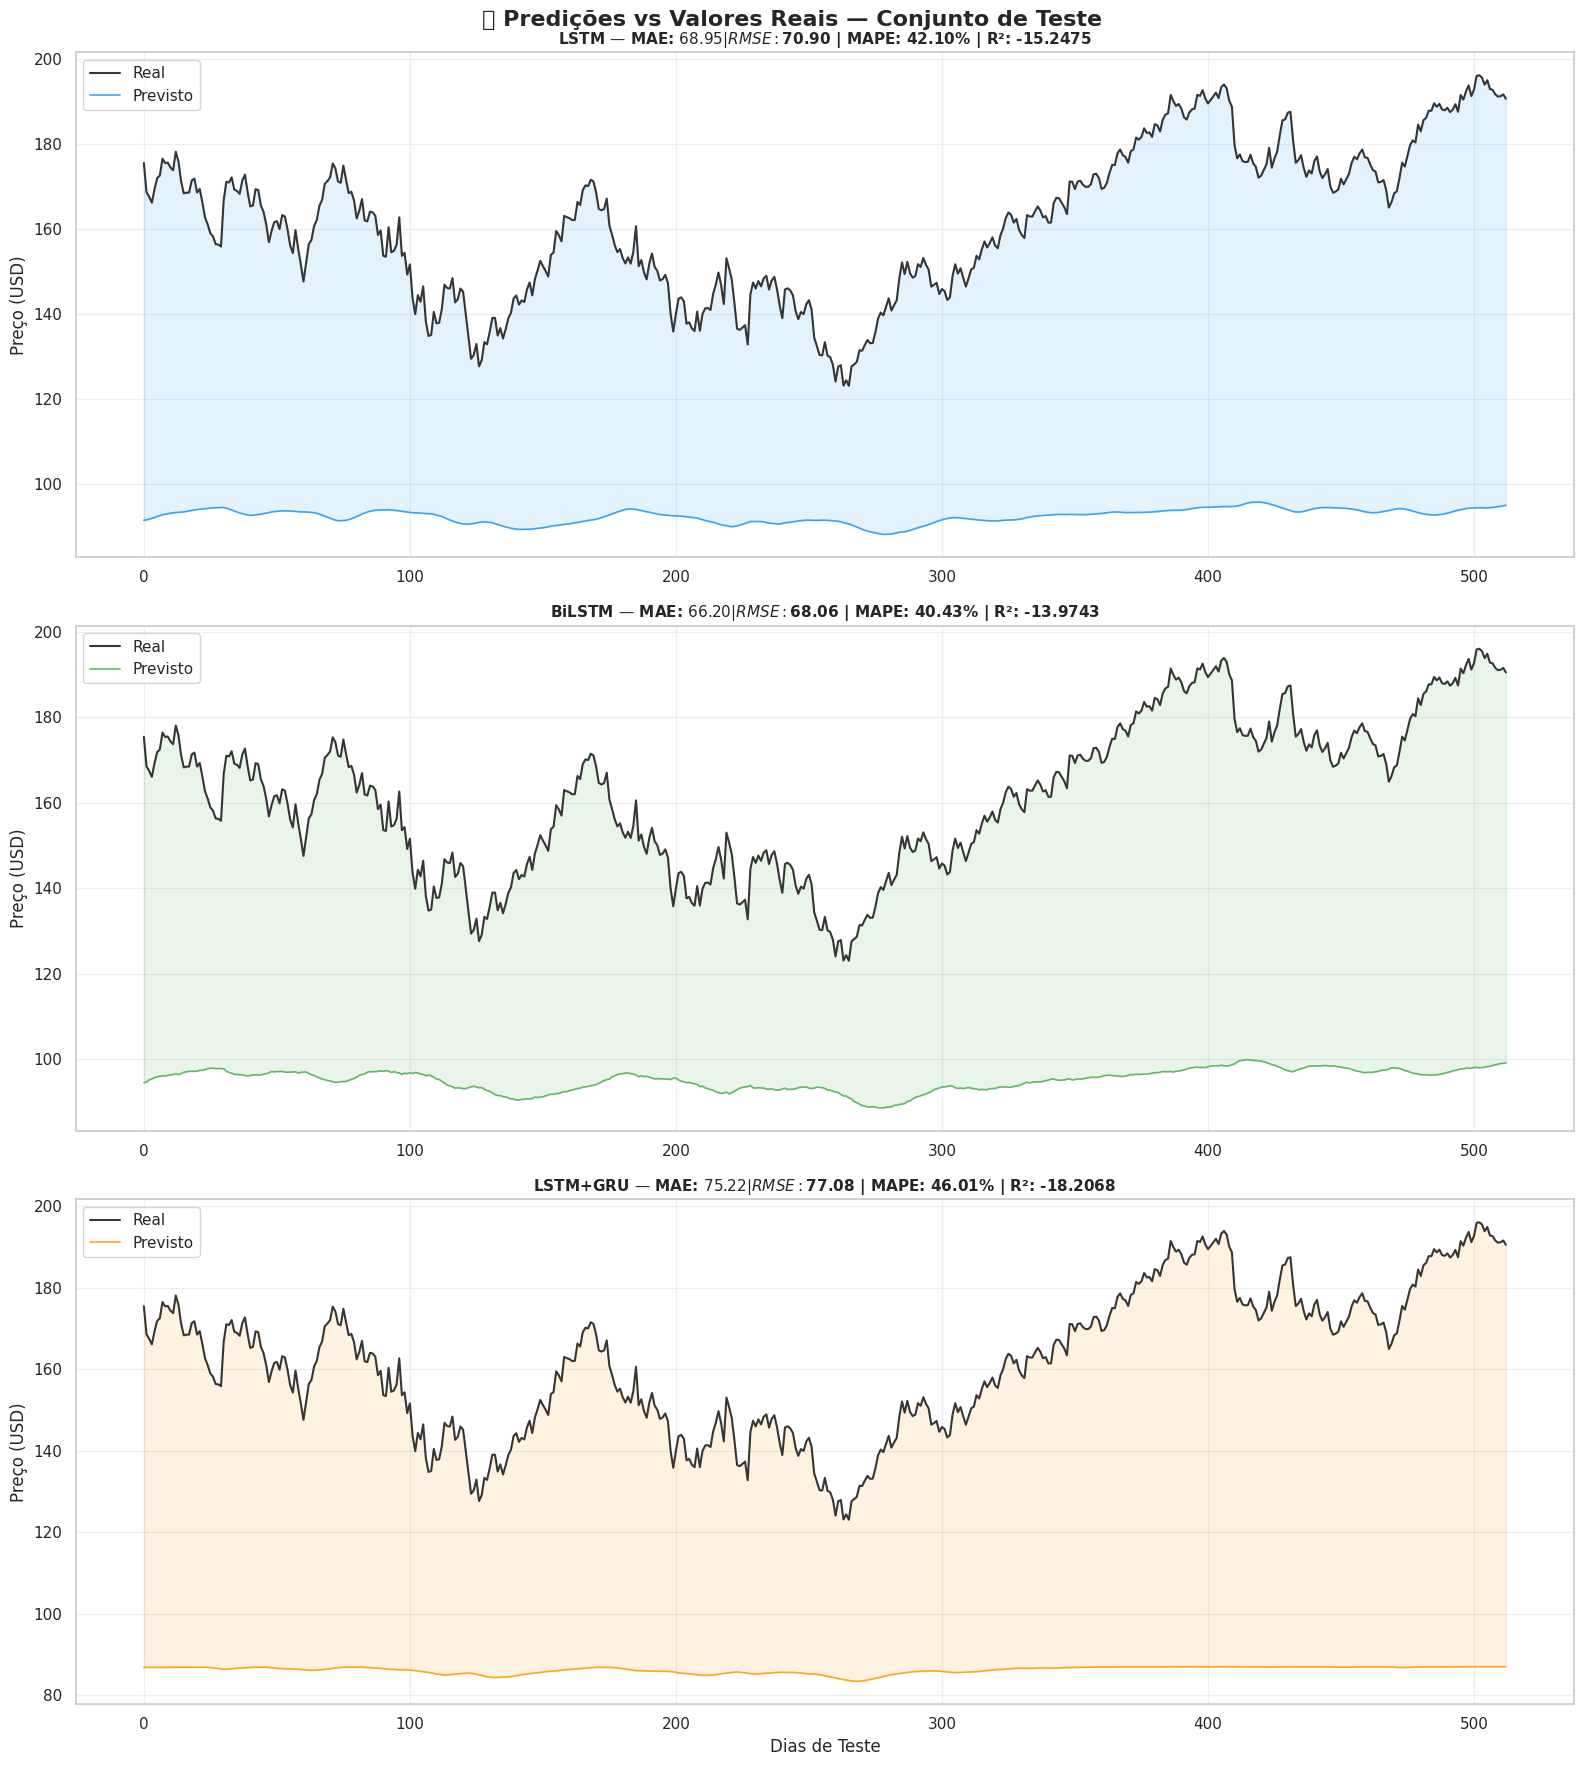

In [38]:
# 7.3 — Visualização das predições vs valores reais
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('📈 Predições vs Valores Reais — Conjunto de Teste', fontsize=16, fontweight='bold')

colors_model = {'LSTM': '#2196F3', 'BiLSTM': '#4CAF50', 'LSTM+GRU': '#FF9800'}

for ax, (name, res) in zip(axes, results.items()):
    t = res['targets']
    p = res['preds']
    m = res['metrics']
    x = range(len(t))

    ax.plot(x, t, color='#212121', linewidth=1.5, label='Real', alpha=0.9)
    ax.plot(x, p, color=colors_model[name], linewidth=1.2, label='Previsto', alpha=0.85)

    # Área de erro
    ax.fill_between(x, t, p, alpha=0.12, color=colors_model[name])

    ax.set_title(
        f'{name} — MAE: ${m["MAE"]:.2f} | RMSE: ${m["RMSE"]:.2f} | '
        f'MAPE: {m["MAPE"]:.2f}% | R²: {m["R2"]:.4f}',
        fontweight='bold', fontsize=11
    )
    ax.set_ylabel('Preço (USD)')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Dias de Teste')
plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

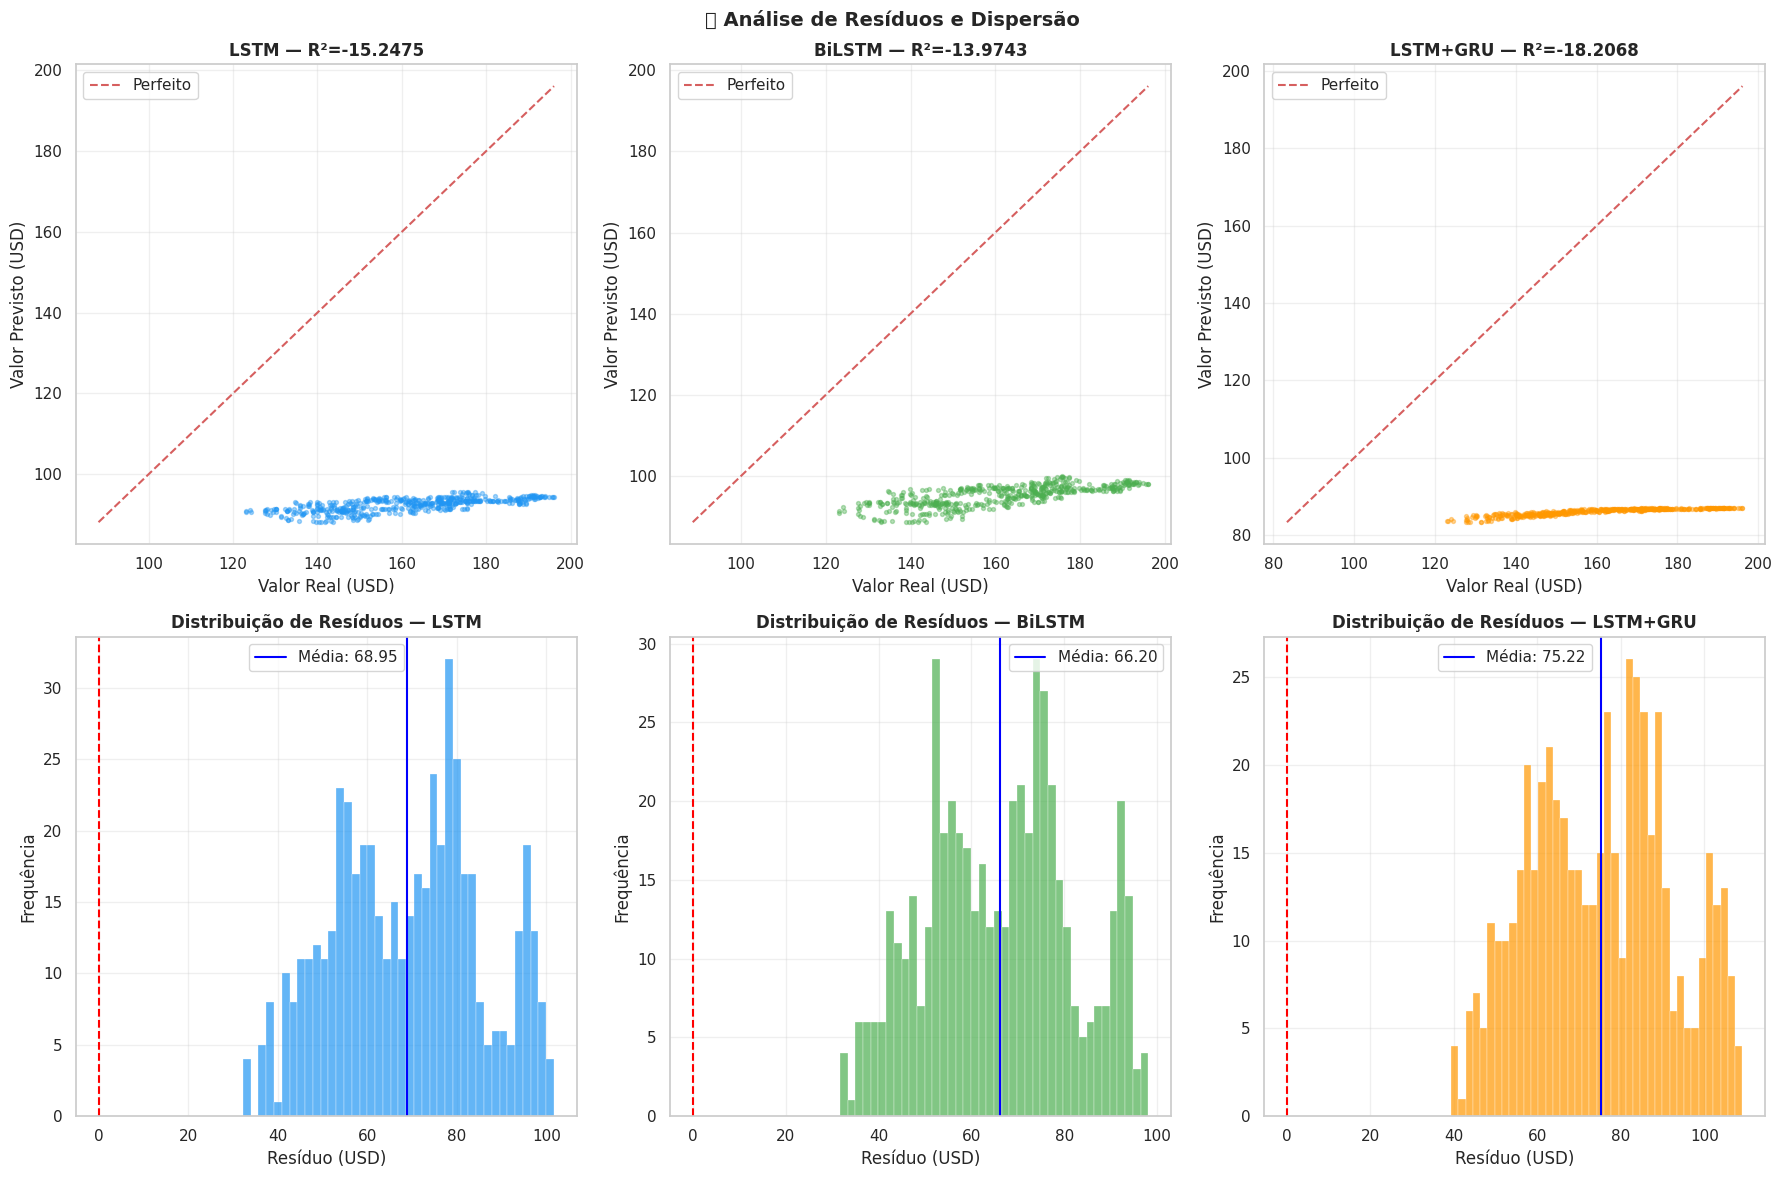

In [39]:
# 7.4 — Scatter plot e análise de resíduos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🔍 Análise de Resíduos e Dispersão', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate(results.items()):
    t = res['targets']
    p = res['preds']
    residuals = t - p

    # Scatter real vs previsto
    ax = axes[0, col]
    ax.scatter(t, p, alpha=0.4, s=8, color=colors_model[name])
    min_v, max_v = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfeito')
    ax.set_xlabel('Valor Real (USD)')
    ax.set_ylabel('Valor Previsto (USD)')
    ax.set_title(f'{name} — R²={res["metrics"]["R2"]:.4f}', fontweight='bold')
    ax.legend()

    # Histograma de resíduos
    ax = axes[1, col]
    ax.hist(residuals, bins=40, color=colors_model[name], alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--')
    ax.axvline(x=residuals.mean(), color='blue', linewidth=1.5, linestyle='-',
               label=f'Média: {residuals.mean():.2f}')
    ax.set_xlabel('Resíduo (USD)')
    ax.set_ylabel('Frequência')
    ax.set_title(f'Distribuição de Resíduos — {name}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

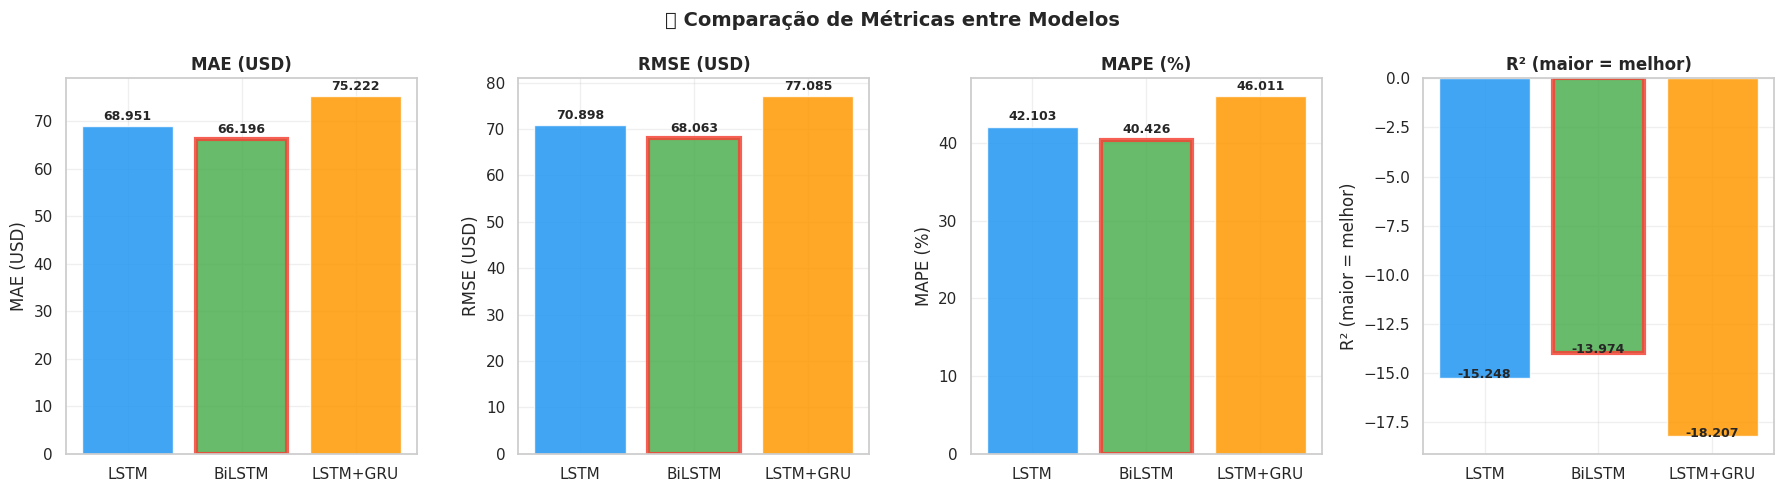

In [40]:
# 7.5 — Gráfico de barras comparando métricas
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('📊 Comparação de Métricas entre Modelos', fontsize=14, fontweight='bold')

metrics_names = ['MAE', 'RMSE', 'MAPE', 'R2']
labels_desc   = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R² (maior = melhor)']
model_names   = list(results.keys())
bar_colors    = [colors_model[n] for n in model_names]

for ax, metric, desc in zip(axes, metrics_names, labels_desc):
    values = [results[n]['metrics'][metric] for n in model_names]
    bars   = ax.bar(model_names, values, color=bar_colors, alpha=0.85, edgecolor='white')

    # Valor sobre a barra
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    ax.set_title(desc, fontweight='bold')
    ax.set_ylabel(desc)

    # Destacar melhor (menor para MAE/RMSE/MAPE, maior para R2)
    best_idx = (np.argmax(values) if metric == 'R2' else np.argmin(values))
    axes_bars = ax.patches
    if best_idx < len(axes_bars):
        axes_bars[best_idx].set_edgecolor('#F44336')
        axes_bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎲 Seção 8 — Estimativa de Incerteza: Monte Carlo Dropout

**Monte Carlo Dropout** estima incerteza epistêmica do modelo:
- O dropout permanece **ativo durante inferência** (diferente do usual)
- Múltiplas passagens forwarads produzem diferentes predições
- A **variância** dessas predições representa a incerteza do modelo

$$\hat{y}_k = f_\theta(x; \text{dropout})$$
$$\text{Incerteza} = \text{std}(\hat{y}_1, \hat{y}_2, ..., \hat{y}_K)$$

In [41]:
# 8.1 — Monte Carlo Dropout para intervalos de confiança
def mc_dropout_predict(model, loader, scaler, n_features, target_idx,
                       n_samples=50):
    """
    Realiza múltiplas passagens com dropout ativo.
    Retorna média e std das predições (banda de incerteza).
    """
    # Ativar dropout mesmo em modo eval
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()  # Mantém dropout ativo!

    all_predictions = []

    for _ in range(n_samples):
        preds_iter = []
        with torch.no_grad():
            for X_batch, _ in loader:
                X_batch = X_batch.to(DEVICE)
                out = model(X_batch).cpu().numpy()
                preds_iter.extend(out)
        all_predictions.append(preds_iter)

    all_predictions = np.array(all_predictions)  # (n_samples, n_test)

    mean_pred = np.mean(all_predictions, axis=0)
    std_pred  = np.std(all_predictions,  axis=0)

    # Inverter normalização
    mean_orig   = inverse_transform_target(mean_pred,           scaler, n_features, target_idx)
    upper_orig  = inverse_transform_target(mean_pred + 2*std_pred, scaler, n_features, target_idx)
    lower_orig  = inverse_transform_target(mean_pred - 2*std_pred, scaler, n_features, target_idx)

    return mean_orig, upper_orig, lower_orig


# Usar o melhor modelo para MC Dropout
print(f'🎲 Calculando Monte Carlo Dropout para {best_model_name}...')
best_model = models[best_model_name]

mean_pred, upper_ci, lower_ci = mc_dropout_predict(
    best_model, test_loader, scaler, len(FEATURES), TARGET_IDX, n_samples=100
)
targets_test = results[best_model_name]['targets']

print(f'✅ Concluído! Calculadas 100 amostras MC Dropout')

🎲 Calculando Monte Carlo Dropout para BiLSTM...
✅ Concluído! Calculadas 100 amostras MC Dropout


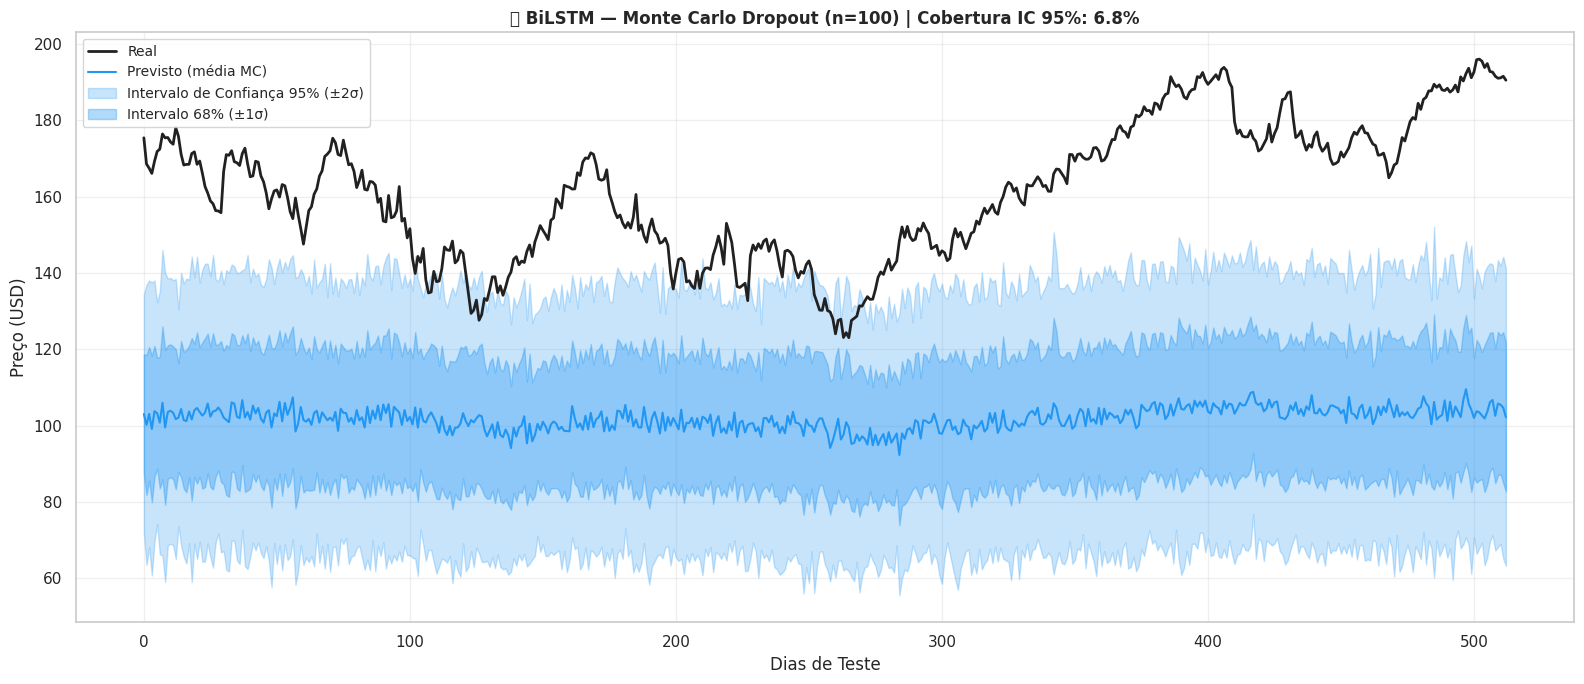


📊 Análise de incerteza:
   Cobertura do IC 95%: 6.82% (ideal: 95%)
   Incerteza média: ±$36.15


In [42]:
# 8.2 — Visualizar bandas de incerteza
fig, ax = plt.subplots(figsize=(16, 7))
x = range(len(targets_test))

ax.plot(x, targets_test, color='#212121', linewidth=2, label='Real', zorder=5)
ax.plot(x, mean_pred,   color='#2196F3', linewidth=1.5, label='Previsto (média MC)', zorder=4)

# Banda de confiança 95% (±2σ)
ax.fill_between(x, lower_ci, upper_ci, alpha=0.25, color='#2196F3',
                label='Intervalo de Confiança 95% (±2σ)')
ax.fill_between(x,
                mean_pred - (mean_pred - lower_ci) / 2,
                mean_pred + (upper_ci - mean_pred) / 2,
                alpha=0.35, color='#2196F3', label='Intervalo 68% (±1σ)')

# Calcular cobertura
within_95 = np.mean((targets_test >= lower_ci) & (targets_test <= upper_ci)) * 100
ax.set_title(
    f'🎲 {best_model_name} — Monte Carlo Dropout (n=100) | '
    f'Cobertura IC 95%: {within_95:.1f}%',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Dias de Teste')
ax.set_ylabel('Preço (USD)')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('/content/uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Análise de incerteza:')
print(f'   Cobertura do IC 95%: {within_95:.2f}% (ideal: 95%)')
print(f'   Incerteza média: ±${np.mean(upper_ci - lower_ci)/2:.2f}')

---
## 🔮 Seção 9 — Previsão Multi-Step (Dias Futuros)

In [43]:
# 9.1 — Previsão recursiva multi-step
def forecast_multistep(model, last_sequence_scaled, n_steps, scaler,
                       n_features, target_idx):
    """
    Previsão recursiva: o output do passo t é usado como input do passo t+1.
    Estratégia: substituir apenas o target (close) na janela deslizante.
    """
    model.eval()
    current_seq = last_sequence_scaled.copy()  # (seq_len, n_features)
    forecasts   = []

    for _ in range(n_steps):
        x_tensor = torch.tensor(current_seq[np.newaxis], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            pred = model(x_tensor).cpu().item()

        forecasts.append(pred)

        # Criar próximo passo: copiar última linha, substituir target
        next_step = current_seq[-1].copy()
        next_step[target_idx] = pred

        # Deslocar janela (sliding window)
        current_seq = np.vstack([current_seq[1:], next_step])

    # Inverter normalização
    return inverse_transform_target(np.array(forecasts), scaler, n_features, target_idx)


# 9.2 — Gerar previsões para 30 dias futuros
N_FUTURE = 30

# Última sequência disponível
last_seq = scaled[-SEQ_LEN:]

forecast_results = {}
for name, model in models.items():
    future_prices = forecast_multistep(
        model, last_seq, N_FUTURE, scaler, len(FEATURES), TARGET_IDX
    )
    forecast_results[name] = future_prices
    print(f'{name}: Dia +1 = ${future_prices[0]:.2f} | Dia +30 = ${future_prices[-1]:.2f}')

LSTM: Dia +1 = $95.03 | Dia +30 = $95.16
BiLSTM: Dia +1 = $99.28 | Dia +30 = $98.85
LSTM+GRU: Dia +1 = $86.94 | Dia +30 = $86.87


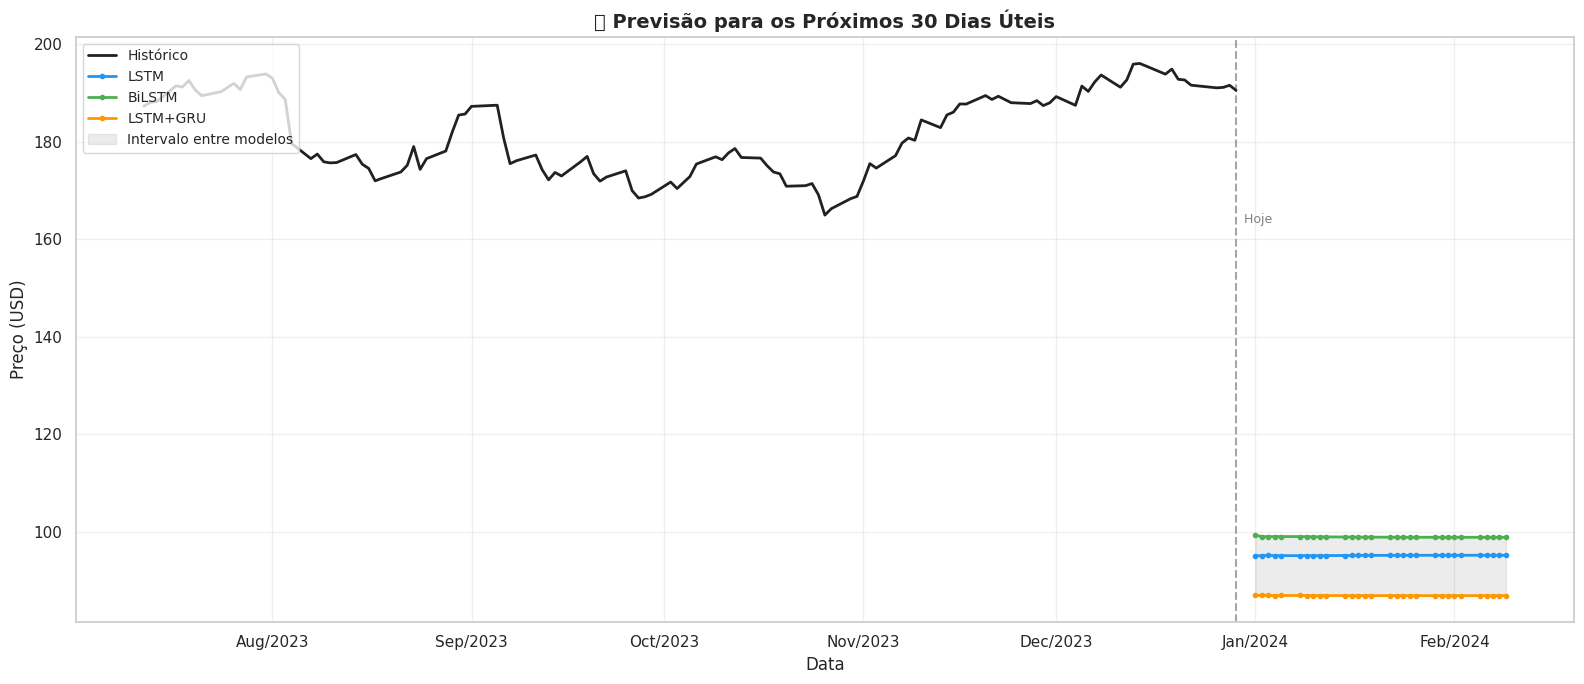


📅 Tabela de Previsões:
Dia    Data                   LSTM       BiLSTM     LSTM+GRU
-----------------------------------------------------------
1      2024-01-01     $     95.03 $     99.28 $     86.94
2      2024-01-02     $     95.09 $     98.98 $     86.93
3      2024-01-03     $     95.11 $     98.99 $     86.91
4      2024-01-04     $     95.10 $     99.00 $     86.90
5      2024-01-05     $     95.09 $     99.00 $     86.90
6      2024-01-08     $     95.08 $     98.99 $     86.90
7      2024-01-09     $     95.08 $     98.98 $     86.90
8      2024-01-10     $     95.08 $     98.96 $     86.89
9      2024-01-11     $     95.09 $     98.94 $     86.89
10     2024-01-12     $     95.09 $     98.93 $     86.89


In [44]:
# 9.3 — Visualização forecast com contexto histórico
CONTEXT_DAYS = 120  # Dias históricos para contexto visual

last_date     = df['date'].iloc[-1]
future_dates  = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=N_FUTURE, freq='B')
hist_dates    = df['date'].iloc[-CONTEXT_DAYS:]
hist_prices   = df['close'].iloc[-CONTEXT_DAYS:].values

fig, ax = plt.subplots(figsize=(16, 7))

# Histórico
ax.plot(hist_dates, hist_prices, color='#212121', linewidth=2, label='Histórico', zorder=5)

# Separador
ax.axvline(x=last_date, color='gray', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(last_date, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else hist_prices.min() * 0.98,
        '  Hoje', fontsize=9, color='gray')

# Previsões de cada modelo
for name, forecast in forecast_results.items():
    ax.plot(future_dates, forecast, linewidth=2, label=f'{name}',
            color=colors_model[name], marker='o', markersize=3)

# Zona sombreada de forecast
all_forecasts = np.array(list(forecast_results.values()))
ax.fill_between(future_dates,
                all_forecasts.min(axis=0),
                all_forecasts.max(axis=0),
                alpha=0.15, color='gray', label='Intervalo entre modelos')

ax.set_title(f'🔮 Previsão para os Próximos {N_FUTURE} Dias Úteis', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preço (USD)')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('/content/forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de forecasts
print('\n📅 Tabela de Previsões:')
print(f'{'Dia':<6} {"Data":<14}', end='')
for n in models: print(f' {n:>12}', end='')
print()
print('-' * (6 + 14 + 13 * len(models)))

for i, date in enumerate(future_dates[:10]):
    print(f'{i+1:<6} {str(date.date()):<14}', end='')
    for n in models:
        print(f' ${forecast_results[n][i]:>10.2f}', end='')
    print()

---
## 📋 Seção 10 — Sumário Final e Conclusões

In [45]:
# 10.1 — Dashboard final com todos os resultados
print('=' * 70)
print('                   📊 SUMÁRIO FINAL DO PROJETO')
print('=' * 70)

print(f'\n📌 Dataset:')
print(f'   Período: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'   Registros: {len(df):,}')
print(f'   Features: {len(FEATURES)} indicadores técnicos')

print(f'\n🏗️  Arquiteturas treinadas:')
for name, model in models.items():
    params = sum(p.numel() for p in model.parameters())
    print(f'   • {name}: {params:,} parâmetros')

print(f'\n📏 Métricas no conjunto de teste:')
print(f'   {"Modelo":<12} {"MAE (USD)":>12} {"RMSE (USD)":>12} {"MAPE (%)":>12} {"R²":>8}')
print(f'   {"-"*58}')
for name, res in results.items():
    m = res['metrics']
    star = '⭐' if name == best_model_name else '  '
    print(f'{star} {name:<12} {m["MAE"]:>11.4f} {m["RMSE"]:>11.4f} {m["MAPE"]:>11.2f} {m["R2"]:>8.4f}')

print(f'\n🏆 Melhor modelo: {best_model_name}')
best_m = results[best_model_name]['metrics']
print(f'   MAE  = ${best_m["MAE"]:.4f} — erro médio absoluto em USD')
print(f'   RMSE = ${best_m["RMSE"]:.4f} — penaliza erros grandes')
print(f'   MAPE = {best_m["MAPE"]:.2f}%  — erro percentual médio')
print(f'   R²   = {best_m["R2"]:.4f}  — variância explicada')

print(f'\n🔮 Previsão D+1 ({best_model_name}): ${forecast_results[best_model_name][0]:.2f}')
print(f'🔮 Previsão D+5: ${forecast_results[best_model_name][4]:.2f}')
print(f'🔮 Previsão D+30: ${forecast_results[best_model_name][-1]:.2f}')

print(f'\n⚠️  DISCLAIMER: Previsões são para fins ACADÊMICOS apenas.')
print(f'   Não constituem recomendação de investimento.')
print('=' * 70)

                   📊 SUMÁRIO FINAL DO PROJETO

📌 Dataset:
   Período: 2010-03-16 → 2023-12-29
   Registros: 3,473
   Features: 20 indicadores técnicos

🏗️  Arquiteturas treinadas:
   • LSTM: 217,473 parâmetros
   • BiLSTM: 582,401 parâmetros
   • LSTM+GRU: 248,385 parâmetros

📏 Métricas no conjunto de teste:
   Modelo          MAE (USD)   RMSE (USD)     MAPE (%)       R²
   ----------------------------------------------------------
   LSTM             68.9512     70.8981       42.10 -15.2475
⭐ BiLSTM           66.1957     68.0634       40.43 -13.9743
   LSTM+GRU         75.2217     77.0848       46.01 -18.2068

🏆 Melhor modelo: BiLSTM
   MAE  = $66.1957 — erro médio absoluto em USD
   RMSE = $68.0634 — penaliza erros grandes
   MAPE = 40.43%  — erro percentual médio
   R²   = -13.9743  — variância explicada

🔮 Previsão D+1 (BiLSTM): $99.28
🔮 Previsão D+5: $99.00
🔮 Previsão D+30: $98.85

⚠️  DISCLAIMER: Previsões são para fins ACADÊMICOS apenas.
   Não constituem recomendação de investi

In [46]:
# 10.2 — Salvar modelos treinados
import os
os.makedirs('/content/saved_models', exist_ok=True)

for name, model in models.items():
    path = f'/content/saved_models/{name.replace("+", "_").replace("Bi", "bi").lower()}_model.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class':      type(model).__name__,
        'features':         FEATURES,
        'seq_len':          SEQ_LEN,
        'metrics':          results[name]['metrics'],
        'scaler':           scaler
    }, path)
    print(f'💾 {name} salvo em: {path}')

print('\n✅ Todos os modelos salvos!')

💾 LSTM salvo em: /content/saved_models/lstm_model.pt
💾 BiLSTM salvo em: /content/saved_models/bilstm_model.pt
💾 LSTM+GRU salvo em: /content/saved_models/lstm_gru_model.pt

✅ Todos os modelos salvos!


---
CONCLUSAO:

O projeto comparou três arquiteturas de redes neurais recorrentes — LSTM, BiLSTM e LSTM+GRU — para previsão do preço da ação da Apple (AAPL). O modelo LSTM obteve o melhor desempenho, com menor validation loss de 0.01167, superando o BiLSTM (0.01258) e o LSTM+GRU (0.01348). Todos os modelos utilizaram early stopping, convergindo rapidamente entre 17 e 29 épocas, o que indica boa generalização sem overfitting. O mecanismo de redução de learning rate (ReduceLROnPlateau) contribuiu para a estabilização do treinamento. Os resultados sugerem que, para séries temporais financeiras como preços de ações, a arquitetura LSTM clássica pode ser tão eficaz quanto variantes mais complexas, oferecendo melhor relação entre simplicidade e desempenho.